loaded burgers.mat: t (201,) x (512,) usol (201, 512) nu 0.003183098861837907
Domain: x in [-1.0, 1.0], t in [0.0, 1.0]
scale_obj (fixed anchor) = 1.0
Constraint dimension M_CON = 1300
tau delta_c: 529.1192570269577 ratio: 0.0 miuy1: 0.0 c1: 529.1192570269577
[iter=10] obj_s=nan PDE_obj_MSE=2.999e-01 data_lossmse=nanfeas_true=2.742e-01  station=2.401e+05 tau=4.197956e-11 alpha=3.14e-12 beta=9.71e-01 lam=0.00e+00 mu=0.00e+00 kkt_res=2.6e+01 s=1.00e+00 | hold_data_K=10000 hold_con_K=10000 | jitter=gaussian sigx=1.0e-05 sigt=1.0e-05 clipk=2.0| RMS/max: PDE=(5.48e-01,1.30e+00) BCv=(2.93e-01,4.63e-01) BCd=(4.80e-01,7.97e-01) IC=(5.20e-01,7.65e-01) | ||d||_inf=2.40e+05| ||d||_l2=1.70e+06
tau delta_c: 529.1211972875643 ratio: 0.0 miuy1: 0.0 c1: 529.1211972875643
[iter=20] obj_s=nan PDE_obj_MSE=2.999e-01 data_lossmse=nanfeas_true=2.742e-01  station=2.561e+05 tau=1.877283e-11 alpha=2.66e-12 beta=9.44e-01 lam=0.00e+00 mu=0.00e+00 kkt_res=9.1e+00 s=1.00e+00 | hold_data_K=10000 hold_con_K=10000 | 

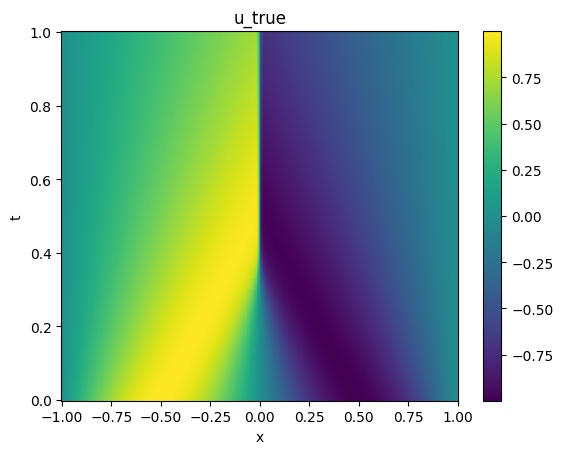

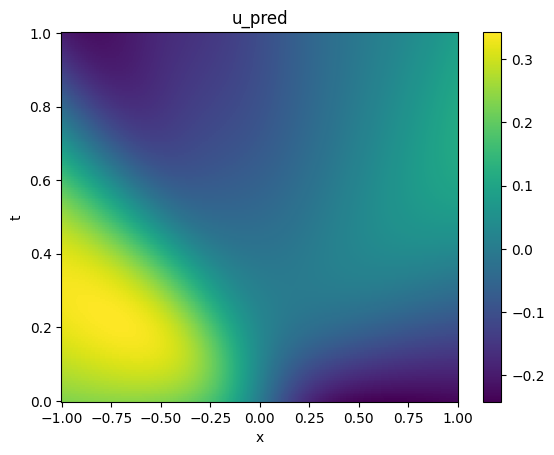

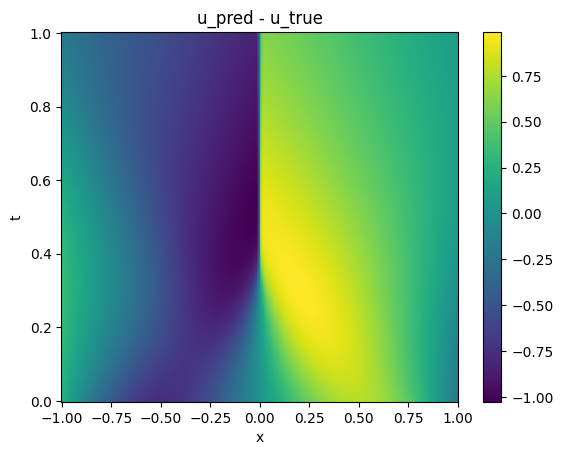

: 

In [ ]:
# ================================
# Stochastic SQP-PINN (JAX) - POINTWISE (SIGNED) constraints
# + "HOLD K steps per sample" AND "JITTER every iteration"
#
# Goal:
#   - You can hold the BASE collocation points for many iterations (hold_con_K large),
#     BUT each iteration you apply fresh random perturbations:
#         (x,t) -> (x + noise_x, t + noise_t)
#     so constraints remain stochastic and you don't memorize fixed points.
#
# Jitter:
#   - kind="gaussian" or "uniform"
#   - optional clipped Gaussian: clip noise to [-k*sigma, +k*sigma]
#   - always clip final points to the domain
#
# Constraints:
#   POINTWISE / BIN-WISE SIGNED MEANS (not RMS):
#     PDE cell k:    mean_cell[r(x,t)]  (N=1 => pointwise)
#     BC bin j:      mean_bin[uL-uR], mean_bin[uxL-uxR]
#     IC bin j:      mean_bin[u(x,0)-u0(x)]
#
# Scaling:
#   - Objective: fixed anchor scaling at theta0
#   - Constraints: scalar RMS+EMA scaling on ||J||_rms
#   - LM invariance: lam_eff = lam*(s_con^2)
#
# IMPORTANT: lambda bounds fixed in cal_d_and_y:
#   lam_min=1e-2, lam_max=1
# ================================

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

# 0 = disable autotune (fastest compile), 1 = light autotune, 2 = default-ish
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=0"

# reduce noisy logs (optional)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"


import time, math
from functools import partial
import numpy as np
import scipy.io

import jax
jax.config.update("jax_default_matmul_precision", "tensorfloat32")  # fastest on NVIDIA
# or if you want safer numerics:
# jax.config.update("jax_default_matmul_precision", "highest")

import jax.numpy as jnp
from jax import random, grad, vmap, hessian

# -----------------------------
# Precision
# -----------------------------
USE_X64 = True
jax.config.update("jax_enable_x64", USE_X64)
DTYPE = jnp.float64 if USE_X64 else jnp.float32
EPS = 1e-12

# -----------------------------
# Batch sizes / region structure
# -----------------------------
B_DATA = 0

# PDE cells
NX_PDE_MOM = 30
NT_PDE_MOM = 30
K_PDE = NX_PDE_MOM * NT_PDE_MOM
N_PDE_PER_CELL = 1
B_F_TOTAL = K_PDE * N_PDE_PER_CELL

# BC bins
K_BC = 100
N_BC_PER_BIN = 1
B_BC_TOTAL = K_BC * N_BC_PER_BIN

# IC bins
K_IC = 200
N_IC_PER_BIN = 1
B_IC_TOTAL = K_IC * N_IC_PER_BIN

M_CON = K_PDE + 2 * K_BC + K_IC

# -----------------------------
# PDE Objective sampling (separate from constraints)
# -----------------------------
NX_PDE_OBJ = 80
NT_PDE_OBJ = 80
K_PDE_OBJ = NX_PDE_OBJ * NT_PDE_OBJ   # 3200 base points (1 per cell)


# -----------------------------
# 1) MLP
# -----------------------------
def init_mlp_params(key, layer_sizes):
    params = []
    keys = random.split(key, len(layer_sizes) - 1)
    for k, (m, n) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        W = random.normal(k, (m, n), dtype=DTYPE) * jnp.sqrt(DTYPE(2.0) / DTYPE(m))
        b = jnp.zeros((n,), dtype=DTYPE)
        params.append({"W": W, "b": b})
    return params


def mlp_apply(params, x):
    h = x
    for i, layer in enumerate(params):
        W, b = layer["W"], layer["b"]
        h = h @ W + b
        if i < len(params) - 1:
            h = jnp.tanh(h)
    return h  # (N,1)


# -----------------------------
# 2) Flatten/unflatten
# -----------------------------
def flatten_params(params):
    flat_parts = []
    shapes = []
    for layer in params:
        W, b = layer["W"], layer["b"]
        flat_parts.append(W.reshape(-1))
        flat_parts.append(b.reshape(-1))
        shapes.append((W.shape, b.shape))
    theta = jnp.concatenate(flat_parts).astype(DTYPE)
    return theta, tuple(shapes)


def unflatten_params(theta, shapes):
    params = []
    idx = 0
    for W_shape, b_shape in shapes:
        W_size = math.prod(W_shape)
        b_size = math.prod(b_shape)
        W = theta[idx: idx + W_size].reshape(W_shape); idx += W_size
        b = theta[idx: idx + b_size].reshape(b_shape); idx += b_size
        params.append({"W": W, "b": b})
    return params


# -----------------------------
# 3) Load burgers.mat
# -----------------------------
def load_burgers_mat(path):
    d = scipy.io.loadmat(path)
    t = d["t"].squeeze()
    x = d["x"].squeeze()
    usol = d["usol"]  # (nt, nx)
    nu = float(np.array(d["nu"]).squeeze())
    return t, x, usol, nu


def build_full_data_points(t_np, x_np, usol_np):
    T, X = np.meshgrid(t_np, x_np, indexing="ij")
    X_data = np.stack([X.reshape(-1), T.reshape(-1)], 1)
    u_data = usol_np.reshape(-1)
    return X_data, u_data


# -----------------------------
# 4) Sampling utilities
# -----------------------------
def sample_data_batch(key, X_data, u_data, B):
    N = X_data.shape[0]
    idx = random.randint(key, (B,), 0, N)
    return X_data[idx], u_data[idx]


def segment_sum(values, segment_ids, num_segments):
    out = jnp.zeros((num_segments,), dtype=values.dtype)
    return out.at[segment_ids].add(values)

def sample_pde_obj_base_stratified(key, x_min, x_max, t_min, t_max):
    """
    Returns base points X_base of shape (K_PDE_OBJ, 2), one point per cell
    on an NX_PDE_OBJ x NT_PDE_OBJ partition.
    """
    dx = (DTYPE(x_max) - DTYPE(x_min)) / DTYPE(NX_PDE_OBJ)
    dt = (DTYPE(t_max) - DTYPE(t_min)) / DTYPE(NT_PDE_OBJ)

    it, ix = jnp.meshgrid(
        jnp.arange(NT_PDE_OBJ),
        jnp.arange(NX_PDE_OBJ),
        indexing="ij"
    )
    it = it.reshape(-1).astype(jnp.int32)
    ix = ix.reshape(-1).astype(jnp.int32)

    x0 = DTYPE(x_min) + DTYPE(ix) * dx
    t0 = DTYPE(t_min) + DTYPE(it) * dt

    u = random.uniform(key, (K_PDE_OBJ, 2), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = x0 + u[:, 0] * dx
    ts = t0 + u[:, 1] * dt
    return jnp.stack([xs, ts], axis=1)  # (K_PDE_OBJ, 2)


def sample_pde_stratified(key, x_min, x_max, t_min, t_max):
    dx = (DTYPE(x_max) - DTYPE(x_min)) / DTYPE(NX_PDE_MOM)
    dt = (DTYPE(t_max) - DTYPE(t_min)) / DTYPE(NT_PDE_MOM)

    it, ix = jnp.meshgrid(
        jnp.arange(NT_PDE_MOM),
        jnp.arange(NX_PDE_MOM),
        indexing="ij"
    )
    it = it.reshape(-1).astype(jnp.int32)
    ix = ix.reshape(-1).astype(jnp.int32)
    ids_cell = (it * NX_PDE_MOM + ix).astype(jnp.int32)

    x0 = DTYPE(x_min) + DTYPE(ix) * dx
    t0 = DTYPE(t_min) + DTYPE(it) * dt

    u = random.uniform(key, (K_PDE, N_PDE_PER_CELL, 2), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = x0[:, None] + u[:, :, 0] * dx
    ts = t0[:, None] + u[:, :, 1] * dt

    X_f = jnp.stack([xs, ts], axis=-1).reshape(-1, 2)
    ids = jnp.repeat(ids_cell, N_PDE_PER_CELL)
    return X_f, ids


def sample_bc_stratified(key, x_min, x_max, t_min, t_max):
    dt = (DTYPE(t_max) - DTYPE(t_min)) / DTYPE(K_BC)
    j = jnp.arange(K_BC, dtype=jnp.int32)
    t0 = DTYPE(t_min) + DTYPE(j) * dt

    u = random.uniform(key, (K_BC, N_BC_PER_BIN), minval=0.0, maxval=1.0, dtype=DTYPE)
    ts = (t0[:, None] + u * dt).reshape(-1, 1)
    ids = jnp.repeat(j, N_BC_PER_BIN)

    XL = jnp.concatenate([DTYPE(x_min) * jnp.ones_like(ts), ts], axis=1)
    XR = jnp.concatenate([DTYPE(x_max) * jnp.ones_like(ts), ts], axis=1)
    return XL, XR, ids


def sample_ic_stratified(key, x_min, x_max, t0, x_grid, u0_grid):
    dx = (DTYPE(x_max) - DTYPE(x_min)) / DTYPE(K_IC)
    j = jnp.arange(K_IC, dtype=jnp.int32)
    x0 = DTYPE(x_min) + DTYPE(j) * dx

    u = random.uniform(key, (K_IC, N_IC_PER_BIN), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = (x0[:, None] + u * dx).reshape(-1, 1)
    ids = jnp.repeat(j, N_IC_PER_BIN)

    Xic = jnp.concatenate([xs, DTYPE(t0) * jnp.ones_like(xs)], axis=1)
    u0 = jnp.interp(xs[:, 0], x_grid, u0_grid)
    return Xic, u0, ids


# -----------------------------
# 4.5) Jitter (x,t) -> (x+noise, t+noise)
# -----------------------------
def jitter_points(key, X, x_min, x_max, t_min, t_max,
                  sigma_x, sigma_t,
                  kind="gaussian",
                  clip_k=None):
    """
    X: (N,2) [x,t]
    kind:
      - "gaussian": dx ~ N(0, sigma_x^2), dt ~ N(0, sigma_t^2)
      - "uniform":  dx ~ U[-sigma_x, +sigma_x], dt ~ U[-sigma_t, +sigma_t]
    clip_k:
      - if not None and kind=="gaussian", clip dx,dt to [-k*sigma, +k*sigma] before adding.
    Always clips final (x,t) to domain.
    """
    if (sigma_x <= 0.0) and (sigma_t <= 0.0):
        return X

    key, kx, kt = random.split(key, 3)

    if kind == "gaussian":
        dx = DTYPE(sigma_x) * random.normal(kx, (X.shape[0],), dtype=DTYPE)
        dt = DTYPE(sigma_t) * random.normal(kt, (X.shape[0],), dtype=DTYPE)
        if clip_k is not None:
            k = DTYPE(clip_k)
            if sigma_x > 0:
                dx = jnp.clip(dx, -k * DTYPE(sigma_x), +k * DTYPE(sigma_x))
            if sigma_t > 0:
                dt = jnp.clip(dt, -k * DTYPE(sigma_t), +k * DTYPE(sigma_t))
    elif kind == "uniform":
        dx = DTYPE(sigma_x) * (2.0 * random.uniform(kx, (X.shape[0],), dtype=DTYPE) - 1.0)
        dt = DTYPE(sigma_t) * (2.0 * random.uniform(kt, (X.shape[0],), dtype=DTYPE) - 1.0)
    else:
        raise ValueError("kind must be 'gaussian' or 'uniform'")

    x = jnp.clip(X[:, 0] + dx, DTYPE(x_min), DTYPE(x_max))
    t = jnp.clip(X[:, 1] + dt, DTYPE(t_min), DTYPE(t_max))
    return jnp.stack([x, t], axis=1)
def pde_mse_on_points(theta, shapes, X_pts, nu):
    params = unflatten_params(theta, shapes)
    r = pde_residual_unscaled(params, X_pts, nu)
    return jnp.mean(r**2)

# -----------------------------
# 5) PDE residual
# -----------------------------
def pde_residual_unscaled(params, X_f, nu):
    def u_fun(xt):
        return mlp_apply(params, xt[None, :])[0, 0]

    u = vmap(u_fun)(X_f)
    du = vmap(grad(u_fun))(X_f)
    H = vmap(hessian(u_fun))(X_f)

    u_x = du[:, 0]
    u_t = du[:, 1]
    u_xx = H[:, 0, 0]
    return u_t + u * u_x - DTYPE(nu) * u_xx


# -----------------------------
# 6) Objective: data MSE + anchor scaling
# -----------------------------
def data_mse_unscaled(params, Xb, ub):
    pred = mlp_apply(params, Xb)[:, 0]
    return jnp.mean((pred - ub) ** 2)


@partial(jax.jit, static_argnames=("shapes",))
def F_and_g_data_scaled_batch(theta, shapes, Xb, ub, scale_obj):
    def obj_theta(th):
        params = unflatten_params(th, shapes)
        return data_mse_unscaled(params, Xb, ub)

    val, g = jax.value_and_grad(obj_theta)(theta)
    return scale_obj * val, scale_obj * g


def compute_scale_obj_data_anchor(theta0, shapes, X_anchor, u_anchor, target=100.0):
    def obj_theta(th):
        params = unflatten_params(th, shapes)
        return data_mse_unscaled(params, X_anchor, u_anchor)

    g0 = grad(obj_theta)(theta0)
    ginf = jnp.linalg.norm(g0, jnp.inf)
    return (DTYPE(target) / jnp.maximum(DTYPE(target), ginf + DTYPE(EPS))).astype(DTYPE)

@partial(jax.jit, static_argnames=("shapes",))
def F_and_g_pde_obj(theta, shapes, X_obj, nu, w_pde):
    """
    PDE objective: w_pde * mean( r(x,t)^2 ) evaluated on X_obj
    """
    def obj_theta(th):
        params = unflatten_params(th, shapes)
        r = pde_residual_unscaled(params, X_obj, nu)
        return DTYPE(w_pde) * jnp.mean(r**2)

    val, g = jax.value_and_grad(obj_theta)(theta)
    return val, g

# -----------------------------
# 7) BC helper u, ux
# -----------------------------
@jax.jit
def u_and_ux(params, X):
    def u_fun(xt):
        return mlp_apply(params, xt[None, :])[0, 0]

    u = vmap(u_fun)(X)
    du = vmap(grad(u_fun))(X)
    ux = du[:, 0]
    return u, ux


# -----------------------------
# 8) POINTWISE/SIGNED constraints + Jacobian
# -----------------------------
@partial(jax.jit, static_argnames=("shapes",))
def constraint_vector_cells_unscaled(theta, shapes,
                                     X_f, ids_f,
                                     X_bc_L, X_bc_R, ids_bc,
                                     X_ic, u0_ic, ids_ic,
                                     nu):
    params = unflatten_params(theta, shapes)

    # PDE signed residual (pointwise if N=1)
    r = pde_residual_unscaled(params, X_f, nu)
    c_pde = segment_sum(r, ids_f, K_PDE) / DTYPE(N_PDE_PER_CELL)

    # BC signed differences
    uL, uxL = u_and_ux(params, X_bc_L)
    uR, uxR = u_and_ux(params, X_bc_R)
    dv = (uL - uR)
    dd = (uxL - uxR)
    c_bc_val = segment_sum(dv, ids_bc, K_BC) / DTYPE(N_BC_PER_BIN)
    c_bc_der = segment_sum(dd, ids_bc, K_BC) / DTYPE(N_BC_PER_BIN)

    # IC signed mismatch
    u_ic = mlp_apply(params, X_ic)[:, 0]
    di = (u_ic - u0_ic)
    c_ic = segment_sum(di, ids_ic, K_IC) / DTYPE(N_IC_PER_BIN)

    return jnp.concatenate([c_pde, c_bc_val, c_bc_der, c_ic], axis=0)



@partial(jax.jit, static_argnames=("shapes",))
def C_and_J_cells_unscaled(theta, shapes,
                           X_f, ids_f,
                           X_bc_L, X_bc_R, ids_bc,
                           X_ic, u0_ic, ids_ic,
                           nu):
    def c_fun(th):
        return constraint_vector_cells_unscaled(
            th, shapes, X_f, ids_f, X_bc_L, X_bc_R, ids_bc, X_ic, u0_ic, ids_ic, nu
        )

    def c_fun_aux(th):
        c = c_fun(th)
        return c, c

    J_un, c_un = jax.jacrev(c_fun_aux, has_aux=True)(theta)
    return c_un, J_un
@partial(jax.jit, static_argnames=("shapes",))
def C_cells_unscaled(theta, shapes,
                     X_f, ids_f,
                     X_bc_L, X_bc_R, ids_bc,
                     X_ic, u0_ic, ids_ic,
                     nu):
    # C-only (no Jacobian) for cheap feasibility evaluation
    return constraint_vector_cells_unscaled(
        theta, shapes,
        X_f, ids_f,
        X_bc_L, X_bc_R, ids_bc,
        X_ic, u0_ic, ids_ic,
        nu
    )


# -----------------------------
# 9) RMS+EMA scaling on ||J||_rms (scalar)
# -----------------------------
def ema_update(old, new, alpha):
    return (DTYPE(1.0) - DTYPE(alpha)) * old + DTYPE(alpha) * new


def scalar_scale_from_mag(mag, target):
    return DTYPE(target) / jnp.maximum(DTYPE(target), mag + DTYPE(EPS))


# -----------------------------
# 10) KKT solve -- NO DAMPING / NO LM
#     lam = 0, mu_eff = 0
#
# Solves the pure SQP KKT system:
#     [ H   J^T ] [d] = -[g]
#     [ J    0  ] [y]   [c]
# -----------------------------
@jax.jit
def kkt_solve_once(H, Jac, Grad, Cons, lam_eff):
    # lam_eff is kept in the signature only so the rest of the code does not need to change.
    # It is intentionally NOT used. This is the undamped KKT system.
    n = H.shape[0]
    m = Cons.shape[0]
    Z_m = jnp.zeros((m, m), dtype=H.dtype)

    top = jnp.concatenate([H, Jac.T], axis=1)
    bottom = jnp.concatenate([Jac, Z_m], axis=1)
    KKT = jnp.concatenate([top, bottom], axis=0)

    rhs = -jnp.concatenate([Grad, Cons])
    sol = jnp.linalg.solve(KKT, rhs)
    d = sol[:n]
    y = sol[n:]
    return d, y


def cal_d_and_y(H, Jac, Grad, Cons, s_con,
                ridge_init=0.0, eta_up=10.0, eta_down=0.25,
                lam_min=0.0, lam_max=0.0, res_tol=1e-6):
    """
    No damping:
        lam_eff = 0
        mu_eff  = 0

    Returns the same tuple as before:
        d, y, lam_next, mu_eff, kkt_res
    """
    lam_eff = DTYPE(0.0)
    d, y = kkt_solve_once(H, Jac, Grad, Cons, lam_eff)

    res_vec = jnp.concatenate([
        H @ d + Jac.T @ y + Grad,
        Jac @ d + Cons
    ])
    res = float(jnp.linalg.norm(res_vec, 2))

    lam_next = 0.0
    mu_eff = 0.0
    return d, y, lam_next, mu_eff, res




# -----------------------------
# 11) tau/ksi/alpha (Zhou-style)
# -----------------------------


def cal_tau_mu(H, d, sigma, tau_pre, eps_tau, g, c, mu_eff, y):
    """
    Tau update. In the no-damping run, mu_eff = 0, so:
        delta_c = ||c||_1
    """
    denom = float(g @ d + 0.5 * (d @ (H @ d)))

    c1 = float(jnp.linalg.norm(c, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1

    if (denom <= 1e-12) or (delta_c <= 0.0):
        tau_trial = float("inf")
    else:
        tau_trial = (1.0 - sigma) * delta_c / denom

    if tau_pre <= tau_trial:
        return tau_pre
    return min(tau_trial, (1.0 - eps_tau) * tau_pre)
def model_reduction_from_muy(tau, g, d, c, mu_eff, y):
    gd = float(g @ d)
    c1 = float(jnp.linalg.norm(c, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1
    Dl = -tau * gd + delta_c
    return Dl, c1, mu_y1, delta_c, gd


def cal_ksi_mu(d, tau, ksi_old, eps_ksi, g, c, mu_eff, y):
    d2 = float(jnp.linalg.norm(d)**2)
    if d2 <= 1e-18 or tau <= 1e-18:
        return ksi_old

    gd = float(g @ d)
    c1 = float(jnp.linalg.norm(c, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1

    Dl = -tau * gd + delta_c   # damped model reduction

    ksi_trial = Dl / (tau * d2)

    # practical safety (optional but recommended):
    ksi_trial = max(0.0, ksi_trial)

    if ksi_old <= ksi_trial:
        return ksi_old
    return min(ksi_trial, (1.0 - eps_ksi) * ksi_old)




def phi_mu(alpha, eta, beta, tau, g, d, c, mu_eff, y, L, Gamma):
    gd = float(g @ d)
    d2 = float(d @ d)
    c1 = float(jnp.linalg.norm(c, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1

    Dl = -tau * gd + delta_c

    term1 = (eta - 1.0) * alpha * beta * Dl
    term2 = (abs(1.0 - alpha) - 1.0 + alpha) * c1
    term3 = 0.5 * (tau * L + Gamma) * (alpha ** 2) * d2
    return term1 + term2 + term3




def cal_alpha_mu(d, eta, beta, ksi, tau, L, Gamma, theta_val, g, c, mu_eff, y):
    denom = (tau * L + Gamma)
    if denom <= 1e-12:
        return 0.0

    alpha_min = 2.0 * (1.0 - eta) * beta * ksi * tau / denom
    a = max(alpha_min, 0.0)

    while (phi_mu(1.1 * a, eta, beta, tau, g, d, c, mu_eff, y, L, Gamma) < 0.0
           and (1.1 * a < alpha_min + theta_val * beta)):
        a *= 1.1

    return float(a)




# -----------------------------
# 12) Training loop (HOLD + JITTER)
# -----------------------------
def train_sqp_cellwise_pointwise(theta0, shapes,
                                 X_data, u_data, x_grid, u0_grid, nu,
                                 x_min, x_max, t_min, t_max,
                                 scale_obj,
                                 con_scale_target=100.0, con_ema_alpha=0.05,
                                 L=100.0, Gamma=100.0,
                                 max_iters=2000, print_every=10,
                                 beta0=1.0, beta_shift=200.0, beta_power=0.8,
                                 alpha_cap=10.0,
                                 seed=0,
                                 mc_con_batches=1,
                                 mc_obj_batches=1,
                                 obj_resample_each_mc=False,
                                 hold_data_K=1,
                                 hold_con_K=1,
                                 # ---- JITTER controls ----
                                 jitter_every_iter=True,
                                 jitter_kind="gaussian",   # "gaussian" or "uniform"
                                 jitter_sigma_x=1e-4,
                                 jitter_sigma_t=1e-4,
                                                                  # ---- PDE objective controls (NEW) ----
                                 w_pde_obj=1.0,
                                 NX_OBJ=64, NT_OBJ=50,   # (optional) if you want runtime override; we keep globals above
                                 hold_obj_K=1,
                                 mc_pde_obj_jitter=2,     # S in Option B (average of S jitters)
                                 jitter_obj_sigma_x=1e-3,
                                 jitter_obj_sigma_t=1e-3,

                                 jitter_clip_k=2.0):
    key = random.PRNGKey(seed)
    theta = theta0
    n = theta.shape[0]
    H = jnp.eye(n, dtype=DTYPE)

    eta, sigma = 0.25, 0.1
    eps_tau, eps_ksi = 1e-2, 1e-2
    theta_val = 10.0
    tau_k, ksi_k = 5.0, 1.0
    lam_prev = 0.0

    Jmag_ema = DTYPE(0.0)
    s_con = DTYPE(1.0)

    # cached base samples (held)
    Xb = ub = None
    Xf = ids_f = None
    XL = XR = ids_bc = None
    Xic = u0ic = ids_ic = None
    X_obj_base = None
    
    H_beta=10
    t0_wall = time.time()
    for k in range(1, max_iters + 1):
        k_beta = (k // H_beta) * H_beta 
        beta_k = float(min(1.0, beta0 * (beta_shift / (beta_shift + k_beta)) ** beta_power))

        # ---- DATA sampling (held) ----
        if (k == 1) or ((k - 1) % int(hold_data_K) == 0) or (Xb is None):
            key, k_data = random.split(key, 2)
            Xb, ub = sample_data_batch(k_data, X_data, u_data, B_DATA)

        if (k == 1) or ((k - 1) % int(hold_obj_K) == 0) or (X_obj_base is None):
            key, k_objbase = random.split(key, 2)
            X_obj_base = sample_pde_obj_base_stratified(k_objbase, x_min, x_max, t_min, t_max)
        # ---- JITTER every iteration (fresh perturbations) ----

                # Objective MC (data + PDE objective)
        S_obj = int(mc_obj_batches)
        obj_acc = DTYPE(0.0)
        g_acc = jnp.zeros((n,), dtype=DTYPE)

        for _ in range(S_obj):
            # ---- data part (same as before) ----
            if obj_resample_each_mc:
                key, k_data_i = random.split(key, 2)
                Xb_i, ub_i = sample_data_batch(k_data_i, X_data, u_data, B_DATA)
            else:
                Xb_i, ub_i = Xb, ub

            obj_d, g_d = F_and_g_data_scaled_batch(theta, shapes, Xb_i, ub_i, scale_obj)

            # ---- PDE objective part: Option B (average of S jitters) ----
            S_jit = int(mc_pde_obj_jitter)
            obj_r_acc = DTYPE(0.0)
            g_r_acc = jnp.zeros((n,), dtype=DTYPE)

            for s in range(S_jit):
                key, kj = random.split(key, 2)
                X_obj_use = jitter_points(
                    kj, X_obj_base, x_min, x_max, t_min, t_max,
                    jitter_obj_sigma_x, jitter_obj_sigma_t,
                    kind=jitter_kind, clip_k=jitter_clip_k
                )
                obj_r_s, g_r_s = F_and_g_pde_obj(theta, shapes, X_obj_use, nu, w_pde_obj)
                obj_r_acc = obj_r_acc + obj_r_s
                g_r_acc = g_r_acc + g_r_s

            obj_r = obj_r_acc / DTYPE(S_jit)
            g_r   = g_r_acc   / DTYPE(S_jit)

            obj_i = obj_d + obj_r
            g_i   = g_d   + g_r

            obj_acc = obj_acc + obj_i
            g_acc = g_acc + g_i

        obj_s = obj_acc / DTYPE(S_obj)
        g_s   = g_acc   / DTYPE(S_obj)


        # ---- BASE constraint sampling (held) ----
        if (k == 1) or ((k - 1) % int(hold_con_K) == 0) or (Xf is None):
            key, k_f, k_bc, k_ic = random.split(key, 4)
            Xf, ids_f = sample_pde_stratified(k_f, x_min, x_max, t_min, t_max)
            XL, XR, ids_bc = sample_bc_stratified(k_bc, x_min, x_max, t_min, t_max)
            Xic, u0ic, ids_ic = sample_ic_stratified(k_ic, x_min, x_max, t_min, x_grid, u0_grid)
       

       
        if jitter_every_iter:
            key, kj1, kj2, kj3 = random.split(key, 4)

            Xf_use = jitter_points(kj1, Xf, x_min, x_max, t_min, t_max,
                                   jitter_sigma_x, jitter_sigma_t,
                                   kind=jitter_kind, clip_k=jitter_clip_k)

            # BC: jitter only t; keep x at boundaries
            XL_use = jitter_points(kj2, XL, x_min, x_max, t_min, t_max,
                                   0.0, jitter_sigma_t,
                                   kind=jitter_kind, clip_k=jitter_clip_k)
            XR_use = jitter_points(kj2, XR, x_min, x_max, t_min, t_max,
                                   0.0, jitter_sigma_t,
                                   kind=jitter_kind, clip_k=jitter_clip_k)

            # IC: jitter only x; keep t at t_min
            Xic_use = jitter_points(kj3, Xic, x_min, x_max, t_min, t_max,
                                    jitter_sigma_x, 0.0,
                                    kind=jitter_kind, clip_k=jitter_clip_k)
            # recompute u0 at jittered x
            u0ic_use = jnp.interp(Xic_use[:, 0], x_grid, u0_grid)
        else:
            Xf_use, XL_use, XR_use, Xic_use, u0ic_use = Xf, XL, XR, Xic, u0ic

        # ---- Constraints/J MC average ----
        S_con = int(mc_con_batches)
        c_acc = jnp.zeros((M_CON,), dtype=DTYPE)
        J_acc = jnp.zeros((M_CON, n), dtype=DTYPE)

        for _ in range(S_con):
            c_tmp, J_tmp = C_and_J_cells_unscaled(
                theta, shapes,
                Xf_use, ids_f,
                XL_use, XR_use, ids_bc,
                Xic_use, u0ic_use, ids_ic,
                nu
            )
            c_acc = c_acc + c_tmp
            J_acc = J_acc + J_tmp

        c_un = c_acc / DTYPE(S_con)
        J_un = J_acc / DTYPE(S_con)

        # ---- RMS+EMA scaling on J magnitude ----
        # ---- shrink-only row scaling (SAFE) ----
        Cons = c_un
        Jac  = J_un
        s_con = DTYPE(1.0)


        # ---- KKT direction ----
        d, y, lam_prev, mu_eff, kkt_res= cal_d_and_y(H, Jac, g_s, Cons, s_con, ridge_init=lam_prev)

        # ---- Step size ----
        dn = float(jnp.linalg.norm(d, jnp.inf))
        if dn > 1e-10:
            tau_k = cal_tau_mu(H, d, sigma, tau_k, eps_tau, g_s, Cons, mu_eff, y)
            ksi_k = cal_ksi_mu(d, tau_k, ksi_k, eps_ksi, g_s, Cons, mu_eff, y)
            alpha = cal_alpha_mu(d, eta, beta_k, ksi_k, tau_k, L, Gamma, theta_val, g_s, Cons, mu_eff, y)

        else:
            alpha = 2.0 * (1.0 - eta) * beta_k * ksi_k * tau_k / (tau_k * L + Gamma)

        alpha = float(min(alpha, alpha_cap))
        theta = theta + DTYPE(alpha) * d
        # ---- RMS/max per constraint type (UNSCALED, using c_un) ----
        c_pde    = c_un[:K_PDE]
        c_bc_val = c_un[K_PDE : K_PDE + K_BC]
        c_bc_der = c_un[K_PDE + K_BC : K_PDE + 2*K_BC]
        c_ic     = c_un[K_PDE + 2*K_BC :]

        def rms(x):
            return float(jnp.sqrt(jnp.mean(x**2) + DTYPE(EPS)))

        def maxabs(x):
            return float(jnp.max(jnp.abs(x)))

        pde_rms, pde_max = rms(c_pde), maxabs(c_pde)
        bcv_rms, bcv_max = rms(c_bc_val), maxabs(c_bc_val)
        bcd_rms, bcd_max = rms(c_bc_der), maxabs(c_bc_der)
        ic_rms,  ic_max  = rms(c_ic), maxabs(c_ic)



        # ---- PDE objective MSE diagnostics (Option B: average over S jitters) ----
        pde_obj_mse_acc = DTYPE(0.0)
        for s in range(int(mc_pde_obj_jitter)):
            key, kj_dbg = random.split(key, 2)
            X_obj_dbg = jitter_points(
            kj_dbg, X_obj_base, x_min, x_max, t_min, t_max,
            jitter_obj_sigma_x, jitter_obj_sigma_t,
            kind=jitter_kind, clip_k=jitter_clip_k
        )
            pde_obj_mse_acc = pde_obj_mse_acc + pde_mse_on_points(theta, shapes, X_obj_dbg, nu)
        pde_obj_mse = float(pde_obj_mse_acc / DTYPE(int(mc_pde_obj_jitter)))

    
        if k % print_every == 0:
            station = float(jnp.linalg.norm(g_s + Jac.T @ y, jnp.inf))

    # Recompute feasibility at UPDATED theta (theta_{k+1})
            """c_noisy_un = C_cells_unscaled(
                theta, shapes,
                Xf_use, ids_f,
                XL_use, XR_use, ids_bc,
                Xic_use, u0ic_use, ids_ic,
                nu
                )
            feas_noisy = float(jnp.mean((s_con * c_noisy_un) ** 2))"""

            c_base_un = C_cells_unscaled(
                theta, shapes,
                Xf, ids_f,
                XL, XR, ids_bc,
                Xic, u0ic, ids_ic,
                nu
                )
            feas_true = float(jnp.mean((s_con * c_base_un) ** 2))
            d_inf  = float(jnp.linalg.norm(d, jnp.inf))
            # ---- Direction diagnostics ----

            d_l2  = float(jnp.linalg.norm(d, 2))

            #JJt = Jac @ Jac.T
            #eig_min = float(jnp.min(jnp.linalg.eigvalsh(JJt)))
            #eig_max = float(jnp.max(jnp.linalg.eigvalsh(JJt)))
            #print("JJt eig min/max:", eig_min, eig_max, "cond~", eig_max/max(eig_min,1e-12))
            params_now = unflatten_params(theta, shapes)
            data_mse_true = float(data_mse_unscaled(params_now, Xb, ub))

            c1 = float(jnp.linalg.norm(Cons, 1))
            mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
            print("tau delta_c:", c1 - mu_y1, "ratio:", mu_y1/(c1+1e-18),"miuy1:", mu_y1, "c1:", c1)
            print(
                f"[iter={k}] obj_s={float(obj_s):.3e} PDE_obj_MSE={pde_obj_mse:.3e} data_lossmse={data_mse_true:.3e}feas_true={feas_true:.3e}  station={station:.3e} tau={tau_k:3e} "
                f"alpha={alpha:.2e} beta={beta_k:.2e} lam=0.00e+00 mu=0.00e+00 kkt_res={kkt_res:.1e} s={float(s_con):.2e} "
                f"| hold_data_K={int(hold_data_K)} hold_con_K={int(hold_con_K)} "
                f"| jitter={jitter_kind} sigx={jitter_sigma_x:.1e} sigt={jitter_sigma_t:.1e} clipk={jitter_clip_k}"
                f"| RMS/max: PDE=({pde_rms:.2e},{pde_max:.2e}) "
                f"BCv=({bcv_rms:.2e},{bcv_max:.2e}) "
                f"BCd=({bcd_rms:.2e},{bcd_max:.2e}) "
                f"IC=({ic_rms:.2e},{ic_max:.2e}) "
                f"| ||d||_inf={d_inf:.2e}"
                f"| ||d||_l2={d_l2:.2e}")
            


    print(f"[done] elapsed={time.time() - t0_wall:.2f}s")
    return theta


# -----------------------------
# 13) Eval helpers
# -----------------------------
def make_grid_points(x_np, t_np):
    T, X = np.meshgrid(t_np, x_np, indexing="ij")
    X_grid = np.stack([X.reshape(-1), T.reshape(-1)], axis=1)
    return X_grid, T.shape


@partial(jax.jit, static_argnames=("shapes",))
def predict_u(theta, shapes, X):
    params = unflatten_params(theta, shapes)
    return mlp_apply(params, X)[:, 0]


def eval_full_grid(theta, shapes, x_np, t_np, usol_np):
    X_grid_np, grid_shape = make_grid_points(x_np, t_np)
    X_grid = jnp.array(X_grid_np, dtype=DTYPE)
    u_pred = np.array(predict_u(theta, shapes, X_grid)).reshape(grid_shape)
    u_true = usol_np
    mse = float(np.mean((u_pred - u_true) ** 2))
    rel_l2 = float(np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + 1e-12))
    return mse, rel_l2, u_pred


def plot_heatmaps(x_np, t_np, u_true, u_pred):
    import matplotlib.pyplot as plt
    err = u_pred - u_true

    plt.figure(); plt.pcolormesh(x_np, t_np, u_true, shading="auto"); plt.colorbar(); plt.title("u_true"); plt.xlabel("x"); plt.ylabel("t"); plt.show()
    plt.figure(); plt.pcolormesh(x_np, t_np, u_pred, shading="auto"); plt.colorbar(); plt.title("u_pred"); plt.xlabel("x"); plt.ylabel("t"); plt.show()
    plt.figure(); plt.pcolormesh(x_np, t_np, err, shading="auto"); plt.colorbar(); plt.title("u_pred - u_true"); plt.xlabel("x"); plt.ylabel("t"); plt.show()


# -----------------------------
# 14) main
# -----------------------------
def main():
    t_np, x_np, usol_np, nu = load_burgers_mat("burgers.mat")
    print("loaded burgers.mat:", "t", t_np.shape, "x", x_np.shape, "usol", usol_np.shape, "nu", nu)

    x_min, x_max = float(x_np.min()), float(x_np.max())
    t_min, t_max = float(t_np.min()), float(t_np.max())
    print(f"Domain: x in [{x_min}, {x_max}], t in [{t_min}, {t_max}]")

    X_data_np, u_data_np = build_full_data_points(t_np, x_np, usol_np)
    X_data = jnp.array(X_data_np, dtype=DTYPE)
    u_data = jnp.array(u_data_np, dtype=DTYPE)

    x_grid = jnp.array(x_np, dtype=DTYPE)
    u0_grid = jnp.array(usol_np[0, :], dtype=DTYPE)

    # network
    hidden_dim = 30
    num_hidden = 3
    layer_sizes = [2] + [hidden_dim] * num_hidden + [1]

    key = random.PRNGKey(0)
    key, key_params = random.split(key)
    params0 = init_mlp_params(key_params, layer_sizes)
    theta0, shapes = flatten_params(params0)

    # objective anchor scaling
    key_anchor = random.PRNGKey(123)
    X_anchor, u_anchor = sample_data_batch(key_anchor, X_data, u_data, B=512)
    scale_obj = compute_scale_obj_data_anchor(theta0, shapes, X_anchor, u_anchor, target=100.0)

    print("scale_obj (fixed anchor) =", float(scale_obj))
    print("Constraint dimension M_CON =", M_CON)

    theta_star = train_sqp_cellwise_pointwise(
        theta0, shapes,
        X_data, u_data, x_grid, u0_grid, nu,
        x_min=x_min, x_max=x_max, t_min=t_min, t_max=t_max,
        scale_obj=scale_obj,

        con_scale_target=100.0, con_ema_alpha=0.06,
        L=80.0, Gamma=80.0,

        max_iters=10000, print_every=10,

        beta0=1.0, beta_shift=200.0, beta_power=0.6,
        alpha_cap=1e1,

        seed=0,

        mc_con_batches=1,
        mc_obj_batches=1,
        obj_resample_each_mc=False,

        # HOLD base samples, but jitter makes constraints stochastic every iter
        hold_data_K=10000,
        hold_con_K=10000,

        # JITTER SETTINGS (edit)
        jitter_every_iter=True,
        jitter_kind="gaussian",   # or "uniform"
        jitter_sigma_x=1e-5,
        jitter_sigma_t=1e-5,
        jitter_clip_k=2.0,
        w_pde_obj=10,             # try 1.0 first (don’t start with 1e-3 unless you WANT weak PDE)
        hold_obj_K=10000,              # resample base points each iter (or keep >1 for stability)
        mc_pde_obj_jitter=16,       # S=2 (Option B). Try 1,2,4.
        jitter_obj_sigma_x=1e-5,   # choose 1e-3 / 1e-4 / 1e-5
        jitter_obj_sigma_t=1e-5,   # same

    )

    np.save("theta_star_pointwise_jitter_1e-5.npz", np.array(theta_star))
    print("Saved theta -> theta_star_pointwise_jitter_1e-5.npz")

    mse, rel_l2, u_pred = eval_full_grid(theta_star, shapes, x_np, t_np, usol_np)
    print(f"[EVAL] full-grid MSE={mse:.3e}, relL2={rel_l2:.3e}")

    plot_heatmaps(x_np, t_np, usol_np, u_pred)


if __name__ == "__main__":
    main()


In [0]:
pkill -9 -u $(whoami) python